**Analyzing Global Tourism and its Impact on the Economies of Countries**

# Data Collection

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import warnings
warnings.filterwarnings("ignore")

In [9]:
# reading data from csv file
data_df = pd.read_csv("/content/world_tourism_economy_data.csv")
data_df.head()


,country,country_code,year,tourism_receipts,tourism_arrivals,tourism_exports,tourism_departures,tourism_expenditures,gdp,inflation,unemployment
0,Aruba,ABW,1999,7.820000e+08,9.720000e+05,62.542949,NaN,9.495387,1.722905e+09,2.280372,NaN
1,Africa Eastern and Southern,AFE,1999,8.034209e+09,1.530938e+07,12.204030,NaN,7.760536,2.654293e+11,7.819865,NaN
2,Afghanistan,AFG,1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,1999,1.443613e+09,3.897975e+06,3.974476,NaN,6.147291,1.394683e+11,0.372266,NaN
4,Angola,AGO,1999,3.100000e+07,4.500000e+04,0.583858,NaN,2.489638,6.152923e+09,248.195902,NaN


# Relational Database Creation

In [10]:
# Creating SQLite database connection
conn = sqlite3.connect("tourism_economy.db")
cursor = conn.cursor()

In [11]:
# Creating Tables
cursor.execute('''
CREATE TABLE IF NOT EXISTS Country (
    CountryCode TEXT PRIMARY KEY,
    CountryName TEXT NOT NULL
);
''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS Tourism (
    CountryCode TEXT,
    Year INTEGER,
    TourismReceipts REAL,
    TourismArrivals REAL,
    TourismExports REAL,
    TourismDepartures REAL,
    TourismExpenditures REAL,
    PRIMARY KEY (CountryCode, Year),
    FOREIGN KEY (CountryCode) REFERENCES Country (CountryCode)
);
''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS Economy (
    CountryCode TEXT,
    Year INTEGER,
    GDP REAL,
    Inflation REAL,
    Unemployment REAL,
    PRIMARY KEY (CountryCode, Year),
    FOREIGN KEY (CountryCode) REFERENCES Country (CountryCode)
);
''')

# Database Loading and Data Pre-Processing

In [12]:
# Drop duplicate rows
data_df.drop_duplicates(inplace=True)

In [13]:
# All numeric rows
numeric_columns = [
    'tourism_receipts', 'tourism_arrivals', 'tourism_exports', 'tourism_departures', 'tourism_expenditures', 'gdp', 'inflation', 'unemployment'
]

In [14]:
# Remove invalid rows (those with negative values in numeric fields)
data_df = data_df[(data_df[numeric_columns] >= 0).all(axis=1)]

In [15]:
# Replace NaN in GDP with the median of neighboring years for the same country
def fill_gdp_with_median(group):
    group['gdp'] = group['gdp'].interpolate(method='linear', limit_direction='both')
    return group

data_df = data_df.groupby('country_code').apply(fill_gdp_with_median)

In [16]:
# Handle missing values by filling numeric columns of NaN with 0
data_df[numeric_columns] = data_df[numeric_columns].fillna(0)

In [17]:
# Attribute Transformation by converting GDP to billions
data_df['gdp'] = data_df['gdp'] / 1e9

In [18]:
# Transformed data
data_df

country country_code  year  tourism_receipts  \
country_code                                                       
ALB          537    Albania          ALB  2001      4.510000e+08   
             803    Albania          ALB  2002      4.920000e+08   
             1069   Albania          ALB  2003      5.370000e+08   
             1335   Albania          ALB  2004      7.560000e+08   
             1601   Albania          ALB  2005      8.800000e+08   
...                     ...          ...   ...               ...   
WSM          3452     Samoa          WSM  2011      1.349000e+08   
             3718     Samoa          WSM  2012      1.482000e+08   
             5048     Samoa          WSM  2017      1.670000e+08   
ZWE          3457  Zimbabwe          ZWE  2011      1.640000e+08   
             5585  Zimbabwe          ZWE  2019      2.850000e+08   

                   tourism_arrivals  tourism_exports  tourism_departures  \
country_code                                                               
ALB          537           354000.0        68.520207            955000.0   
             803           470000.0        73.743218           1303000.0   
             1069          557000.0        63.417407           1350000.0   
             1335          645000.0        60.488821           1694000.0   
             1601          748000.0        60.242108           2097000.0   
...                             ...              ...                 ...   
WSM          3452          128000.0        64.732004             57000.0   
             3718          135000.0        66.705953             56000.0   
             5048          158000.0        59.987355             55000.0   
ZWE          3457         2423000.0         3.367463            693000.0   
             5585         2294000.0         5.411115           3275000.0   

                   tourism_expenditures        gdp   inflation  unemployment  
country_code                                                                  
ALB          537              16.864146   3.922101    3.107588        16.400  
             803              21.121635   4.348068    7.770526         4.615  
             1069             22.374900   5.611496    0.484003        15.000  
             1335             23.126809   7.184686    2.280019        14.400  
             1601             23.083412   8.052077    2.366582         6.566  
...                                 ...        ...         ...           ...  
WSM          3452              5.233633   0.744097    5.235416         5.680  
             3718              5.607420   0.773142    2.049019         8.752  
             5048              0.950797   0.884844    1.749897         9.400  
ZWE          3457              3.418711  14.101920    3.466130         5.368  
             5585              4.760583  25.717410  255.304991         7.373  

[1503 rows x 11 columns]

In [19]:
# Extract and insert data into Country table
countries = data_df[['country_code', 'country']].drop_duplicates().values.tolist()
cursor.executemany("INSERT OR IGNORE INTO Country (CountryCode, CountryName) VALUES (?, ?);", countries)

# Extract and insert data into Tourism table
tourism_data = data_df[['country_code', 'year', 'tourism_receipts', 'tourism_arrivals', 'tourism_exports', 'tourism_departures', 'tourism_expenditures']].values.tolist()
cursor.executemany("INSERT OR IGNORE INTO Tourism VALUES (?, ?, ?, ?, ?, ?, ?);", tourism_data)

# Extract and insert data into Economy table
economy_data = data_df[['country_code', 'year', 'gdp', 'inflation', 'unemployment']].values.tolist()
cursor.executemany("INSERT OR IGNORE INTO Economy VALUES (?, ?, ?, ?, ?);", economy_data)

conn.commit()

In [20]:
print("\nCountry Table:")
print(pd.read_sql_query("SELECT * FROM Country;", conn))


Country Table:
    CountryCode    CountryName
0           ALB        Albania
1           ARM        Armenia
2           AUS      Australia
3           AUT        Austria
4           AZE     Azerbaijan
..          ...            ...
109         VEN  Venezuela, RB
110         VUT        Vanuatu
111         WLD          World
112         WSM          Samoa
113         ZWE       Zimbabwe

[114 rows x 2 columns]


In [21]:
print("\nTourism Table:")
print(pd.read_sql_query("SELECT * FROM Tourism;", conn))


Tourism Table:
     CountryCode  Year  TourismReceipts  TourismArrivals  TourismExports  \
0            ALB  2001     4.510000e+08         354000.0       68.520207   
1            ALB  2002     4.920000e+08         470000.0       73.743218   
2            ALB  2003     5.370000e+08         557000.0       63.417407   
3            ALB  2004     7.560000e+08         645000.0       60.488821   
4            ALB  2005     8.800000e+08         748000.0       60.242108   
...          ...   ...              ...              ...             ...   
1498         WSM  2011     1.349000e+08         128000.0       64.732004   
1499         WSM  2012     1.482000e+08         135000.0       66.705953   
1500         WSM  2017     1.670000e+08         158000.0       59.987355   
1501         ZWE  2011     1.640000e+08        2423000.0        3.367463   
1502         ZWE  2019     2.850000e+08        2294000.0        5.411115   

      TourismDepartures  TourismExpenditures  
0              955000.0 

In [22]:
print("\nEconomy Table:")
print(pd.read_sql_query("SELECT * FROM Economy;", conn))


Economy Table:
     CountryCode  Year        GDP   Inflation  Unemployment
0            ALB  2001   3.922101    3.107588        16.400
1            ALB  2002   4.348068    7.770526         4.615
2            ALB  2003   5.611496    0.484003        15.000
3            ALB  2004   7.184686    2.280019        14.400
4            ALB  2005   8.052077    2.366582         6.566
...          ...   ...        ...         ...           ...
1498         WSM  2011   0.744097    5.235416         5.680
1499         WSM  2012   0.773142    2.049019         8.752
1500         WSM  2017   0.884844    1.749897         9.400
1501         ZWE  2011  14.101920    3.466130         5.368
1502         ZWE  2019  25.717410  255.304991         7.373

[1503 rows x 5 columns]


# Exploratory Data Analysis (EDA)

In [23]:
# SQL query to get data for tourism receipts of the US
cursor.execute('''
SELECT t.Year, t.TourismReceipts
FROM Tourism t
JOIN Country c ON t.CountryCode = c.CountryCode
WHERE c.CountryName = 'United States'
ORDER BY t.Year;
''')

# Fetch the results and load them into a Pandas DataFrame
us_tourism_data = cursor.fetchall()
us_tourism_df = pd.DataFrame(us_tourism_data, columns=['Year', 'TourismReceipts'])
print(us_tourism_df)

    Year  TourismReceipts
0   1999     1.091880e+11
1   2000     1.183160e+11
2   2001     1.054540e+11
3   2002     9.741500e+10
4   2003     9.481400e+10
5   2004     1.072100e+11
6   2005     1.166820e+11
7   2006     1.210300e+11
8   2007     1.348000e+11
9   2008     1.490940e+11
10  2010     1.618210e+11
11  2011     1.789350e+11
12  2012     1.951130e+11
13  2013     2.131050e+11
14  2014     2.227460e+11
15  2015     2.305740e+11
16  2016     2.285490e+11
17  2017     2.337580e+11
18  2018     2.419840e+11
19  2019     2.394470e+11
20  2020     8.420500e+10


In [24]:
# Query to get average GDP by country
cursor.execute('''
SELECT CountryName, AVG(GDP) AS AvgGDP
FROM Economy
JOIN Country ON Economy.CountryCode = Country.CountryCode
GROUP BY CountryName
ORDER BY AvgGDP DESC;
''')

# Fetch the results and load them into a Pandas DataFrame
avg_gdp_data = cursor.fetchall()
avg_gdp_df = pd.DataFrame(avg_gdp_data, columns=['CountryName', 'AvgGDP'])
print(avg_gdp_df)

                   CountryName        AvgGDP
0                        World  65034.446119
1                  High income  44040.411991
2                 OECD members  42221.626534
3    Post-demographic dividend  39895.963602
4        Europe & Central Asia  18227.887026
..                         ...           ...
109                       Fiji      3.356067
110                     Bhutan      2.735684
111                 Seychelles      1.367762
112                      Samoa      0.725502
113                    Vanuatu      0.709728

[114 rows x 2 columns]


In [25]:
# Query to get countries with highest and lowest tourism expenditures, sorted in descending order
cursor.execute('''
SELECT CountryName, SUM(TourismExpenditures) AS TotalExpenditures
FROM Tourism
JOIN Country ON Tourism.CountryCode = Country.CountryCode
GROUP BY CountryName
ORDER BY TotalExpenditures DESC;
''')

# Fetch the results and load them into a Pandas DataFrame
tourism_expenditures_data = cursor.fetchall()
tourism_expenditures_df = pd.DataFrame(tourism_expenditures_data, columns=['CountryName', 'TotalExpenditures'])
print(tourism_expenditures_df)

             CountryName  TotalExpenditures
0                Albania         461.773507
1                 Norway         245.462845
2              Australia         238.202764
3     Russian Federation         214.004732
4                Armenia         210.558775
..                   ...                ...
109         Sierra Leone           5.393944
110             Eswatini           4.579524
111          Congo, Rep.           4.422520
112  Trinidad and Tobago           3.263206
113                 Togo           2.698230

[114 rows x 2 columns]


In [26]:
# Query to get data for correlation analysis
cursor.execute('''
SELECT t.Year, t.TourismReceipts, t.TourismArrivals, t.TourismExports,
       t.TourismDepartures, t.TourismExpenditures,
       e.GDP, e.Inflation, e.Unemployment
FROM Tourism t
JOIN Economy e ON t.CountryCode = e.CountryCode AND t.Year = e.Year
ORDER BY t.CountryCode, t.Year;
''')

# Fetch the results and load them into a Pandas DataFrame
correlation_data = cursor.fetchall()
correlation_df = pd.DataFrame(correlation_data, columns=['Year', 'TourismReceipts', 'TourismArrivals', 'TourismExports', 'TourismDepartures', 'TourismExpenditures', 'GDP', 'Inflation', 'Unemployment'])
print(correlation_df)

      Year  TourismReceipts  TourismArrivals  TourismExports  \
0     2001     4.510000e+08         354000.0       68.520207   
1     2002     4.920000e+08         470000.0       73.743218   
2     2003     5.370000e+08         557000.0       63.417407   
3     2004     7.560000e+08         645000.0       60.488821   
4     2005     8.800000e+08         748000.0       60.242108   
...    ...              ...              ...             ...   
1498  2011     1.349000e+08         128000.0       64.732004   
1499  2012     1.482000e+08         135000.0       66.705953   
1500  2017     1.670000e+08         158000.0       59.987355   
1501  2011     1.640000e+08        2423000.0        3.367463   
1502  2019     2.850000e+08        2294000.0        5.411115   

      TourismDepartures  TourismExpenditures        GDP   Inflation  \
0              955000.0            16.864146   3.922101    3.107588   
1             1303000.0            21.121635   4.348068    7.770526   
2             1350

In [27]:
# Query to get the top 10 countries by tourism departures in 2020
cursor.execute('''
SELECT CountryName, SUM(TourismDepartures) AS TotalDepartures
FROM Tourism
JOIN Country ON Tourism.CountryCode = Country.CountryCode
WHERE Year = 2020
GROUP BY CountryName
ORDER BY TotalDepartures DESC
LIMIT 10;
''')

# Fetch the results and load them into a Pandas DataFrame
top_10_departures_data = cursor.fetchall()
top_10_departures_df = pd.DataFrame(top_10_departures_data, columns=['CountryName', 'TotalDepartures'])
print(top_10_departures_df)

          CountryName  TotalDepartures
0       United States     6.054990e+07
1              Mexico     3.605600e+07
2              France     2.128700e+07
3             Hungary     1.272700e+07
4  Russian Federation     1.236100e+07
5             Ukraine     1.125100e+07
6             Romania     9.510000e+06
7             Belgium     5.850000e+06
8         Korea, Rep.     4.276000e+06
9            Bulgaria     3.973000e+06


In [28]:
# Query to get total tourism arrivals and departures by country
cursor.execute('''
SELECT CountryName,
       SUM(TourismArrivals) AS TotalArrivals,
       SUM(TourismDepartures) AS TotalDepartures
FROM Tourism
JOIN Country ON Tourism.CountryCode = Country.CountryCode
GROUP BY CountryName
ORDER BY TotalArrivals DESC;
''')

# Fetch the results and load them into a Pandas DataFrame
arrivals_departures_data = cursor.fetchall()
arrivals_departures_df = pd.DataFrame(arrivals_departures_data, columns=['CountryName', 'TotalArrivals', 'TotalDepartures'])
print(arrivals_departures_df)

                   CountryName  TotalArrivals  TotalDepartures
0                  High income   2.415120e+10     1.671756e+10
1                        World   2.346149e+10     1.972662e+10
2                 OECD members   2.219433e+10     1.605188e+10
3    Post-demographic dividend   2.041256e+10     1.490411e+10
4        Europe & Central Asia   1.631110e+10     1.002877e+10
..                         ...            ...              ...
109                      Samoa   5.370000e+05     2.190000e+05
110                     Bhutan   3.160000e+05     7.200000e+04
111                Congo, Rep.   2.590000e+05     1.610000e+05
112               Sierra Leone   1.190000e+05     2.050000e+05
113              New Caledonia   1.070000e+05     1.240000e+05

[114 rows x 3 columns]


# Data Visualization

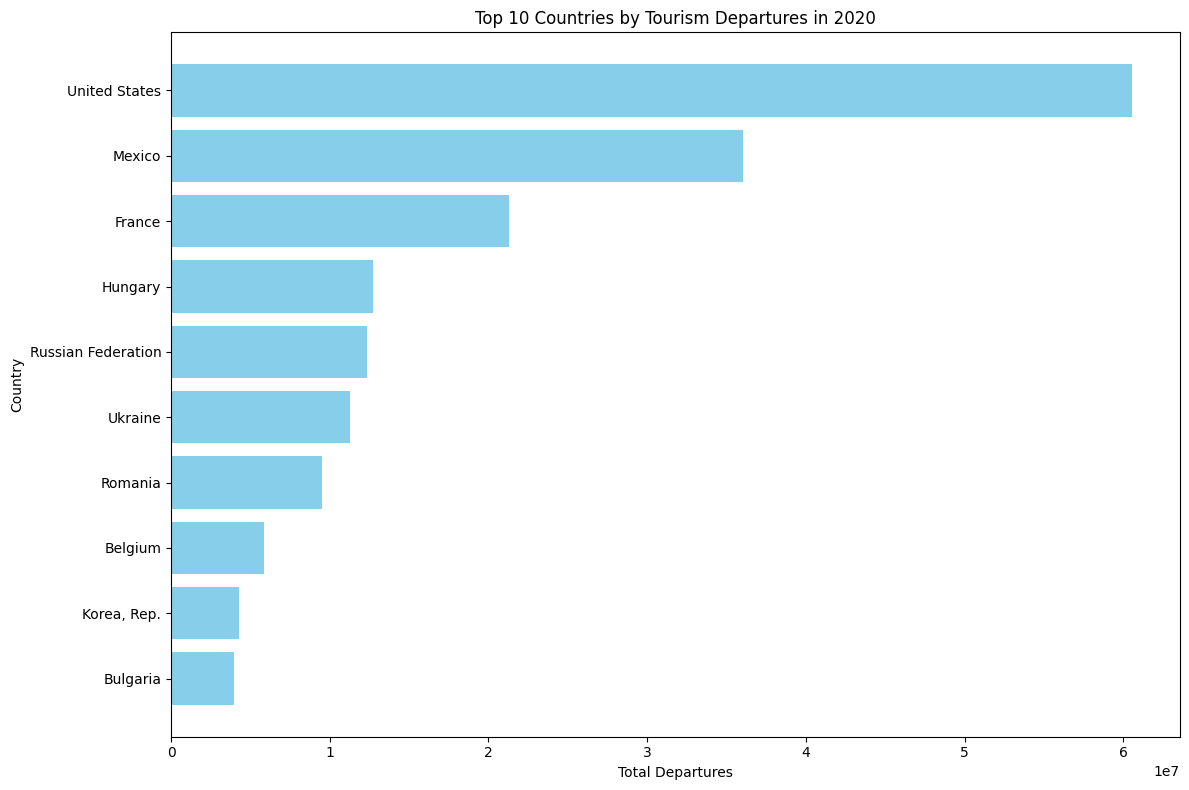

In [29]:
# Creating a bar plot for the top 10 countries by tourism departures in 2020
plt.figure(figsize=(12, 8))
plt.barh(top_10_departures_df['CountryName'], top_10_departures_df['TotalDepartures'], color='skyblue')
plt.xlabel('Total Departures')
plt.ylabel('Country')
plt.title('Top 10 Countries by Tourism Departures in 2020')
plt.gca().invert_yaxis()  # Inverting the y-axis to have the country with the highest departures at the top
plt.tight_layout()
plt.show()

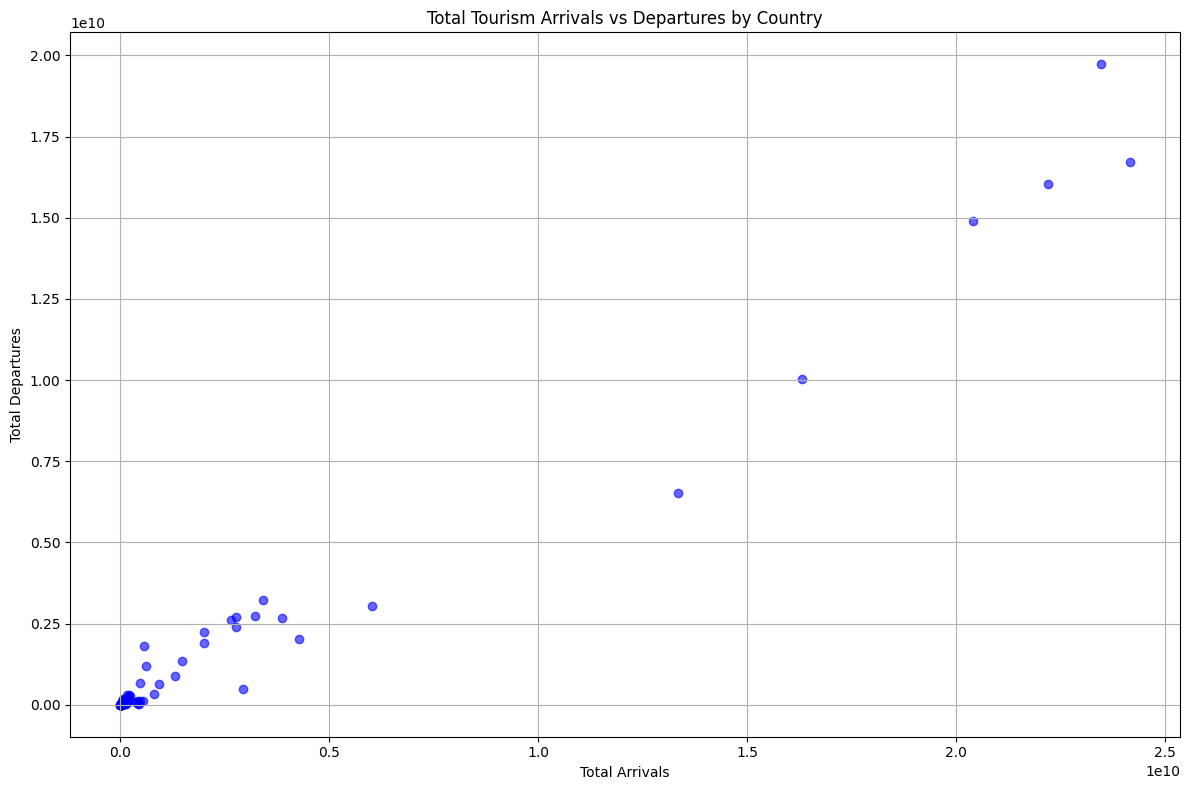

In [30]:
# Scatter plot for total arrivals vs total departures by country
plt.figure(figsize=(12, 8))
plt.scatter(arrivals_departures_df['TotalArrivals'], arrivals_departures_df['TotalDepartures'], color='blue', alpha=0.6)

# Adding labels and title
plt.title('Total Tourism Arrivals vs Departures by Country')
plt.xlabel('Total Arrivals')
plt.ylabel('Total Departures')

# Show grid and plot
plt.grid(True)
plt.tight_layout()
plt.show()

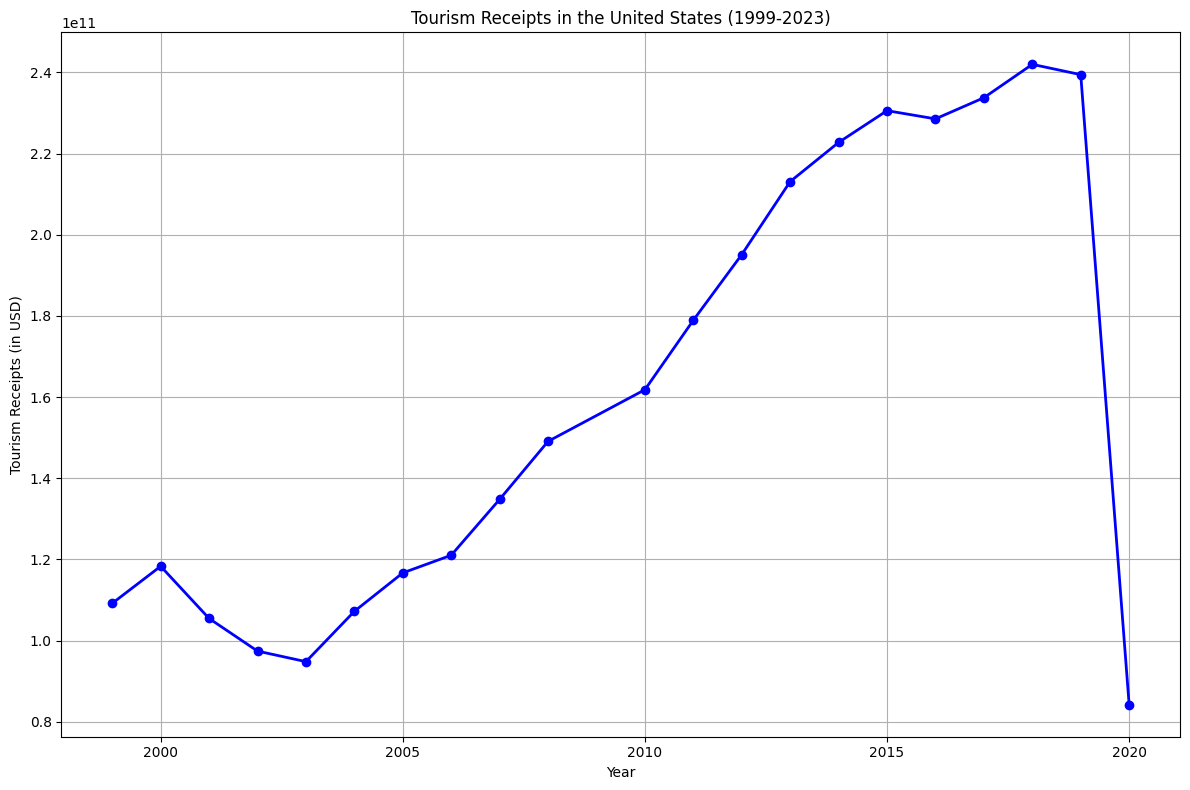

In [31]:
# Plot the tourism receipts over time for the United States
plt.figure(figsize=(12, 8))
plt.plot(us_tourism_df['Year'], us_tourism_df['TourismReceipts'], marker='o', color='b', linestyle='-', linewidth=2, markersize=6)
plt.title('Tourism Receipts in the United States (1999-2023)')
plt.xlabel('Year')
plt.ylabel('Tourism Receipts (in USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

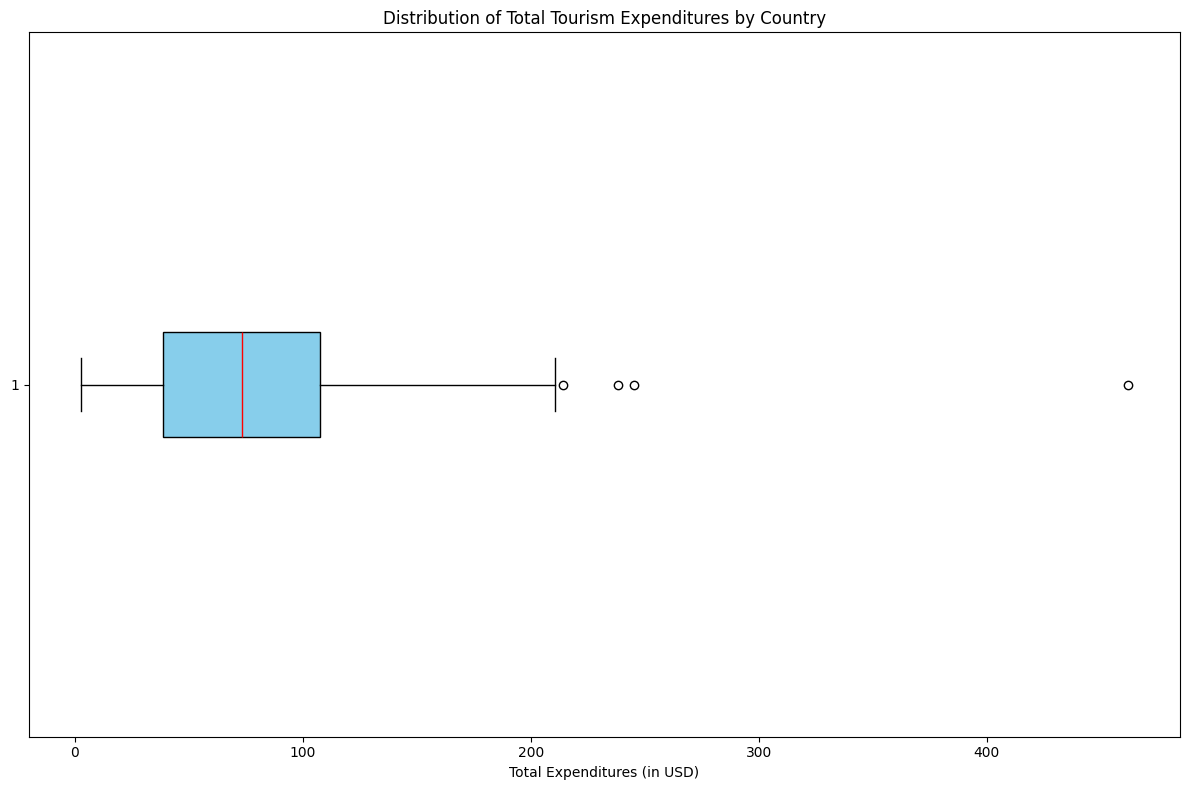

In [32]:
# Create a boxplot for tourism expenditures across all countries
plt.figure(figsize=(12, 8))
plt.boxplot(tourism_expenditures_df['TotalExpenditures'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='skyblue', color='black'),
            medianprops=dict(color='red'))

# Adding labels and title
plt.title('Distribution of Total Tourism Expenditures by Country')
plt.xlabel('Total Expenditures (in USD)')
plt.tight_layout()
plt.show()

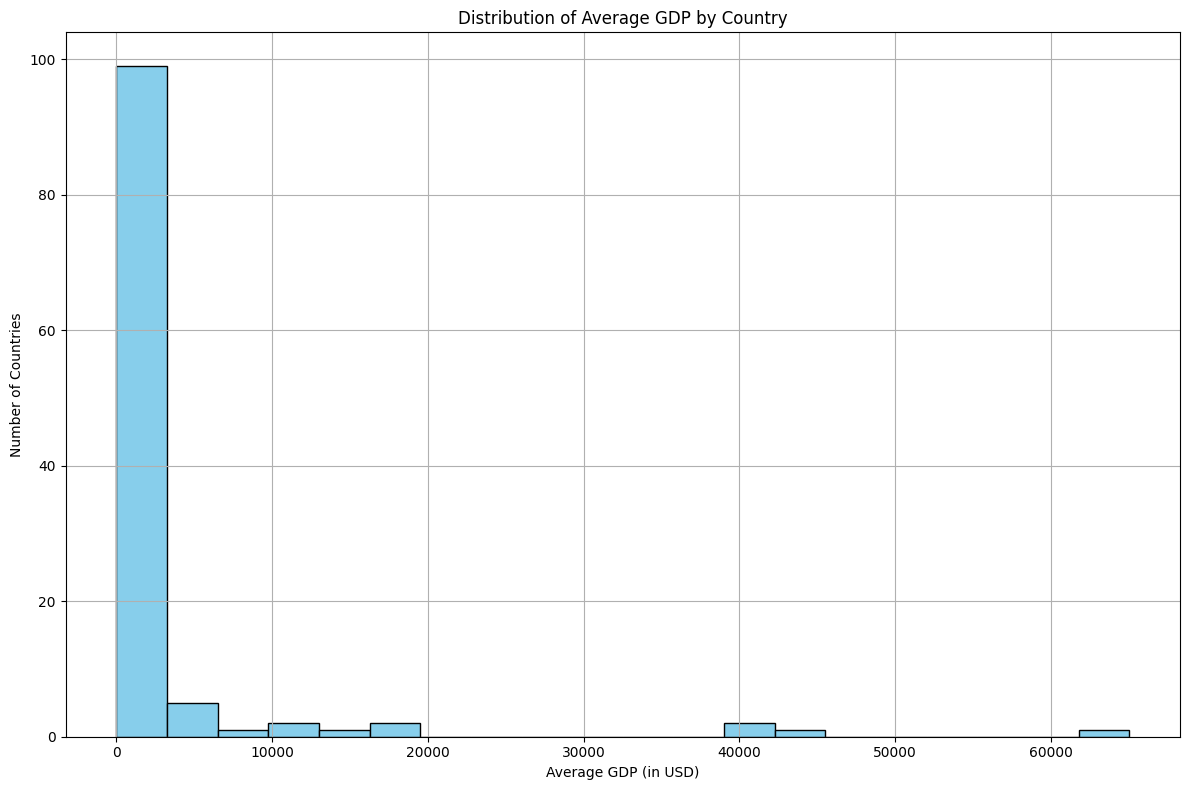

In [33]:
# Plot a histogram for the average GDP values
plt.figure(figsize=(12, 8))
plt.hist(avg_gdp_df['AvgGDP'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Average GDP by Country')
plt.xlabel('Average GDP (in USD)')
plt.ylabel('Number of Countries')
plt.grid(True)
plt.tight_layout()
plt.show()

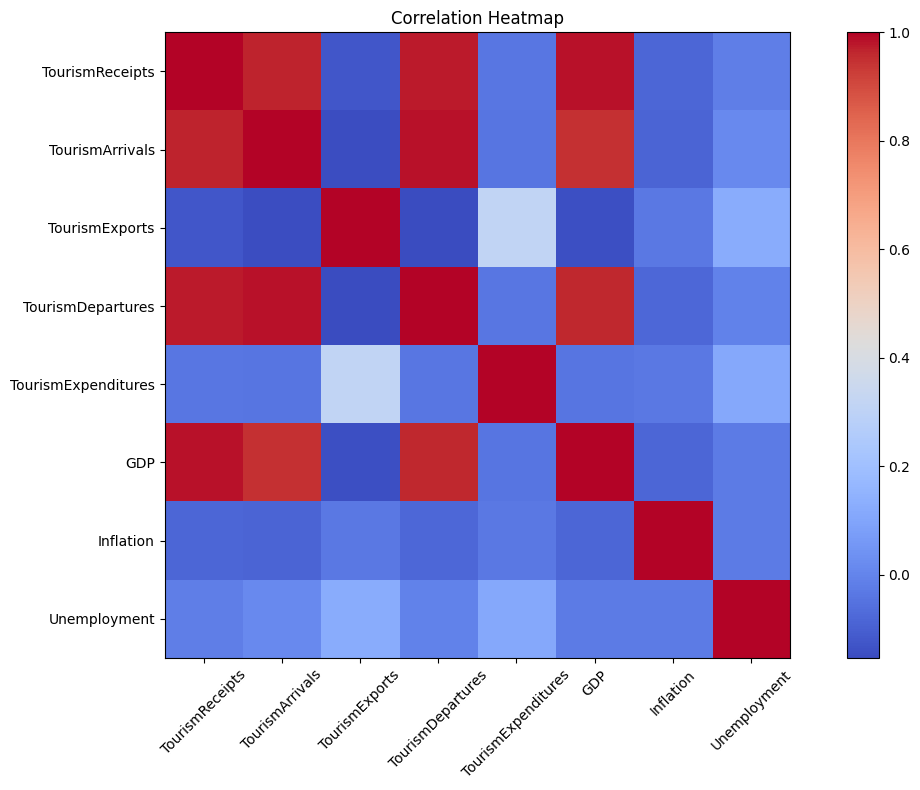

In [34]:
# Compute the correlation matrix for the numeric columns
correlation_matrix = correlation_df[['TourismReceipts', 'TourismArrivals', 'TourismExports',
                                     'TourismDepartures', 'TourismExpenditures', 'GDP',
                                     'Inflation', 'Unemployment']].corr()

# Plot the heatmap using imshow
plt.figure(figsize=(12, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

# Set labels and title
plt.title('Correlation Heatmap')
plt.xticks(np.arange(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(np.arange(len(correlation_matrix.columns)), correlation_matrix.columns)

# Display the heatmap
plt.tight_layout()
plt.show()

In [35]:
conn.close()